# Introduction to Tangent Planes

A guided notebook transcribed and expanded from the Coursera
*Calculus for Machine Learning and Data Science* lecture
*"Introduction to Tangent planes"* (Week 2 — Gradients and Gradient Descent).

This notebook explains:

- how a **tangent line** in 1D generalizes to a **tangent plane** in 2D
- the surface $f(x,y)=x^2+y^2$ and its 3D plot
- the **slicing** idea: fix one variable, get a parabola, differentiate it
- how two tangent lines (one per slice) define the tangent plane
- the tangent-plane equation, with SymPy and numerical checks
- 3D visualizations, exercises, and a summary

This notebook follows the repository `GUIDELINES.md` template.

## 1. Introduction

In Week 1 you studied functions of **one** variable, where the derivative at a point
is the **slope of the tangent line**. We now move to functions of **two or more**
variables.

> *"Things like a tangent line in one dimension will generalize to a tangent plane in
> two dimensions."*

This matters because optimization — including the training of machine-learning models —
almost always happens over functions of many variables. The tangent plane is the first
key concept on the road to **partial derivatives**, the **gradient**, and
**gradient descent**.

After this notebook you will be able to:

- describe a tangent plane as the 2D analogue of a tangent line
- compute it by slicing a surface into two 1D problems
- write down and plot the tangent plane of a surface at a point

## 2. From tangent line to tangent plane

### One variable (recap)

For $f(x)=x^2$ (a parabola), the derivative at a point is the slope of the tangent line.
At $x=2$:

$$
f(2)=4, \qquad f'(x)=2x, \qquad f'(2)=4 .
$$

So the tangent line at the point $(2, 4)$ has slope $4$.

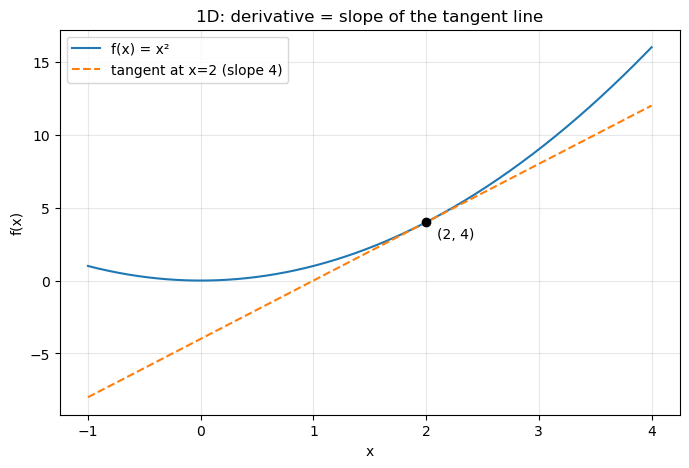

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sympy as sp

x = np.linspace(-1, 4, 400)
y = x**2

a = 2.0
slope = 2 * a               # f'(2) = 4
tangent = a**2 + slope * (x - a)

plt.figure(figsize=(8, 5))
plt.plot(x, y, label="f(x) = x²")
plt.plot(x, tangent, "--", label=f"tangent at x={a:.0f} (slope {slope:.0f})")
plt.plot(a, a**2, "ko")
plt.annotate("(2, 4)", (a, a**2), textcoords="offset points", xytext=(8, -12))
plt.title("1D: derivative = slope of the tangent line")
plt.xlabel("x")
plt.ylabel("f(x)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

### Two variables

Now take a function with two inputs and one output:

$$
f(x,y) = x^2 + y^2 .
$$

It needs **three dimensions** to plot: $x$ and $y$ are the horizontal axes (the floor)
and $z = f(x,y)$ is the height. The surface is a bowl (a *paraboloid*).

Here the tangents are no longer lines — they form a **plane**, the **tangent plane**.

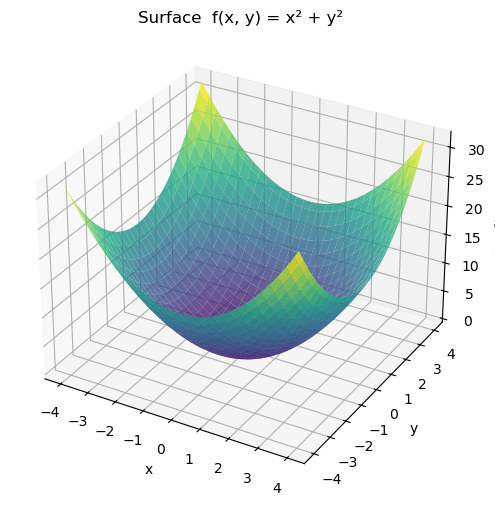

In [2]:
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401  (enables 3D projection)

def f(x, y):
    return x**2 + y**2

gx = np.linspace(-4, 4, 60)
gy = np.linspace(-4, 4, 60)
X, Y = np.meshgrid(gx, gy)
Z = f(X, Y)

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection="3d")
ax.plot_surface(X, Y, Z, cmap="viridis", alpha=0.8)
ax.set_title("Surface  f(x, y) = x² + y²")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("z = f(x, y)")
plt.show()

## 3. The slicing idea

How do we find the tangent plane? The lecture's trick:

> *"It's the same as the 1D case, except we have to take two cases. We cut the space
> into planes and then calculate the tangents on these planes."*

We will build the tangent plane at the point $(x_0, y_0) = (2, 4)$.

### Slice 1 — fix $y = 4$

Setting $y = 4$ slices the surface with a vertical plane. Along that slice the function
becomes a function of $x$ alone:

$$
f(x, 4) = x^2 + 4^2 = x^2 + 16 .
$$

This is just a parabola, so we differentiate with respect to $x$:

$$
\frac{\partial f}{\partial x} = 2x \quad\Rightarrow\quad \text{at } x=2:\; 2(2)=4 .
$$

That slope $4$ is the slope of the **first** tangent line.

### Slice 2 — fix $x = 2$

Setting $x = 2$ slices the other way. Now the function depends on $y$ alone:

$$
f(2, y) = 2^2 + y^2 = 4 + y^2 .
$$

Differentiate with respect to $y$:

$$
\frac{\partial f}{\partial y} = 2y \quad\Rightarrow\quad \text{at } y=4:\; 2(4)=8 .
$$

That slope $8$ is the slope of the **second** tangent line.

These two operations are exactly the **partial derivatives** $f_x$ and $f_y$ — each one
treats the other variable as a constant.

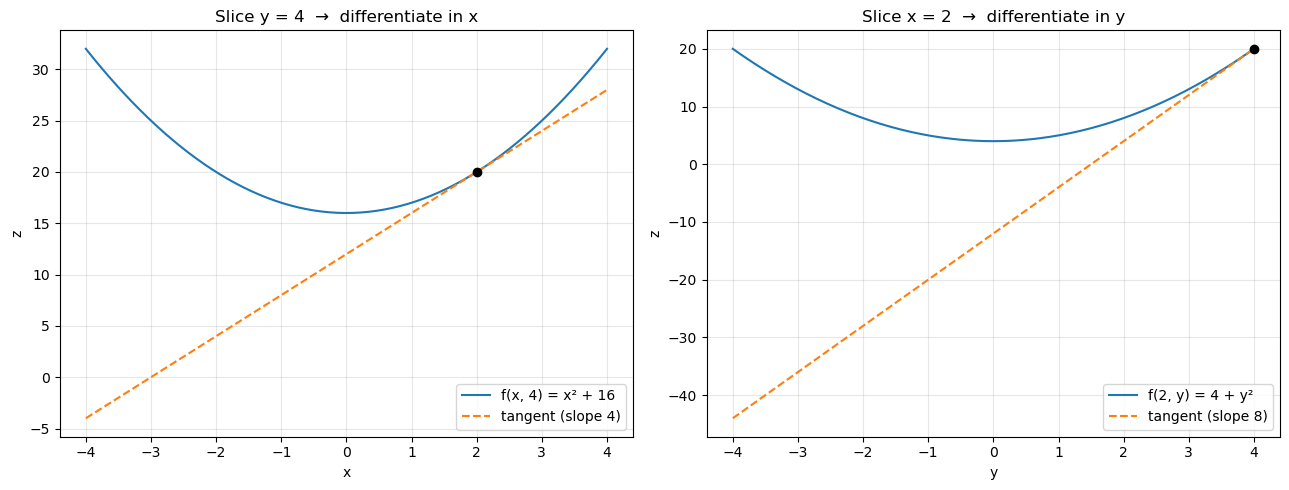

In [3]:
# The two slices through the point (2, 4)
x0, y0 = 2.0, 4.0

t = np.linspace(-4, 4, 200)

slice_y_fixed = t**2 + y0**2     # f(x, 4) = x^2 + 16   (parabola in x)
slice_x_fixed = x0**2 + t**2     # f(2, y) = 4  + y^2   (parabola in y)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(t, slice_y_fixed, label="f(x, 4) = x² + 16")
s1 = 2 * x0
axes[0].plot(t, (x0**2 + y0**2) + s1 * (t - x0), "--",
             label=f"tangent (slope {s1:.0f})")
axes[0].plot(x0, x0**2 + y0**2, "ko")
axes[0].set_title("Slice y = 4  →  differentiate in x")
axes[0].set_xlabel("x")

axes[1].plot(t, slice_x_fixed, label="f(2, y) = 4 + y²")
s2 = 2 * y0
axes[1].plot(t, (x0**2 + y0**2) + s2 * (t - y0), "--",
             label=f"tangent (slope {s2:.0f})")
axes[1].plot(y0, x0**2 + y0**2, "ko")
axes[1].set_title("Slice x = 2  →  differentiate in y")
axes[1].set_xlabel("y")

for ax in axes:
    ax.set_ylabel("z")
    ax.grid(True, alpha=0.3)
    ax.legend()

plt.tight_layout()
plt.show()

## 4. From two tangent lines to the tangent plane

> *"Once we have the two tangent lines, then we have a plane, because any two lines that
> cross actually represent a unique plane."*

The two tangent lines both pass through the surface point
$\big(x_0,\, y_0,\, f(x_0,y_0)\big)$ and point in different directions, so together they
pin down a unique plane. Its equation is

$$
\boxed{\,z = f(x_0,y_0) + f_x(x_0,y_0)\,(x-x_0) + f_y(x_0,y_0)\,(y-y_0)\,}
$$

For $f(x,y)=x^2+y^2$ at $(2,4)$:

$$
f(2,4)=20,\qquad f_x(2,4)=4,\qquad f_y(2,4)=8,
$$

$$
z = 20 + 4(x-2) + 8(y-4).
$$

## 5. Symbolic check with SymPy

In [4]:
xs, ys = sp.symbols('x y')
f_sym = xs**2 + ys**2

fx = sp.diff(f_sym, xs)
fy = sp.diff(f_sym, ys)
print("f(x, y)      =", f_sym)
print("∂f/∂x        =", fx)
print("∂f/∂y        =", fy)

x0, y0 = 2, 4
f0  = f_sym.subs({xs: x0, ys: y0})
fx0 = fx.subs({xs: x0, ys: y0})
fy0 = fy.subs({xs: x0, ys: y0})
print(f"\nAt ({x0}, {y0}): f = {f0}, f_x = {fx0}, f_y = {fy0}")

plane = f0 + fx0 * (xs - x0) + fy0 * (ys - y0)
print("Tangent plane: z =", sp.expand(plane))

f(x, y)      = x**2 + y**2
∂f/∂x        = 2*x
∂f/∂y        = 2*y

At (2, 4): f = 20, f_x = 4, f_y = 8
Tangent plane: z = 4*x + 8*y - 20


## 6. Numerical check of the partial derivatives

Partial derivatives are ordinary 1D derivatives along one axis. We confirm them with a
central finite difference, holding the other variable fixed.

In [5]:
def f(x, y):
    return x**2 + y**2

def partial_x(f, x, y, h=1e-6):
    return (f(x + h, y) - f(x - h, y)) / (2 * h)

def partial_y(f, x, y, h=1e-6):
    return (f(x, y + h) - f(x, y - h)) / (2 * h)

x0, y0 = 2.0, 4.0
print(f"f_x numeric = {partial_x(f, x0, y0):.5f}   (exact 2x = {2*x0:.1f})")
print(f"f_y numeric = {partial_y(f, x0, y0):.5f}   (exact 2y = {2*y0:.1f})")

f_x numeric = 4.00000   (exact 2x = 4.0)
f_y numeric = 8.00000   (exact 2y = 8.0)


## 7. Visualizing the tangent plane on the surface

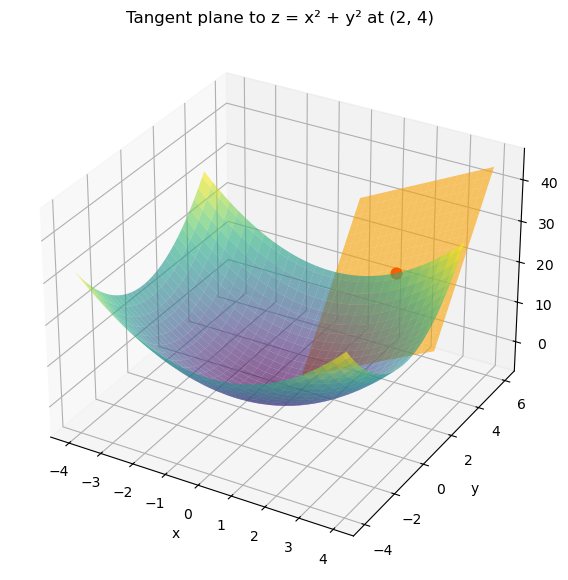

In [6]:
x0, y0 = 2.0, 4.0
f0, fx0, fy0 = x0**2 + y0**2, 2*x0, 2*y0

gx = np.linspace(-4, 4, 60)
gy = np.linspace(-4, 4, 60)
X, Y = np.meshgrid(gx, gy)
Z = X**2 + Y**2

# tangent plane evaluated on a small patch around (x0, y0)
px = np.linspace(x0 - 2, x0 + 2, 20)
py = np.linspace(y0 - 2, y0 + 2, 20)
PX, PY = np.meshgrid(px, py)
PZ = f0 + fx0 * (PX - x0) + fy0 * (PY - y0)

fig = plt.figure(figsize=(9, 7))
ax = fig.add_subplot(111, projection="3d")
ax.plot_surface(X, Y, Z, cmap="viridis", alpha=0.6)
ax.plot_surface(PX, PY, PZ, color="orange", alpha=0.6)
ax.scatter([x0], [y0], [f0], color="red", s=60)
ax.set_title("Tangent plane to z = x² + y² at (2, 4)")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("z")
plt.show()

## 8. Exercises

### Basic
1. For $f(x,y)=x^2+y^2$, state $f_x$ and $f_y$.
2. Evaluate $f_x$ and $f_y$ at the point $(1, 3)$.

### Intermediate
3. Find the tangent plane to $f(x,y)=x^2+y^2$ at $(1, 3)$.
4. For $g(x,y)=x^2 y + 3y$, compute $g_x$ and $g_y$.

### Advanced
5. Find the tangent plane of $h(x,y)=\sin x + y^2$ at $(0, 1)$.
6. Explain in words why "two crossing tangent lines determine a unique plane," and
   what would go wrong if the two slice directions were parallel.

## 9. Solutions / Checks

In [7]:
xs, ys = sp.symbols('x y')

def tangent_plane(expr, x0, y0):
    fx = sp.diff(expr, xs); fy = sp.diff(expr, ys)
    f0 = expr.subs({xs: x0, ys: y0})
    return sp.expand(f0 + fx.subs({xs: x0, ys: y0})*(xs - x0)
                        + fy.subs({xs: x0, ys: y0})*(ys - y0))

f = xs**2 + ys**2
# 1 & 2
print("1. f_x =", sp.diff(f, xs), ", f_y =", sp.diff(f, ys))
print("2. at (1,3): f_x =", sp.diff(f, xs).subs({xs:1, ys:3}),
      ", f_y =", sp.diff(f, ys).subs({xs:1, ys:3}))
# 3
print("3. tangent plane at (1,3): z =", tangent_plane(f, 1, 3))
# 4
g = xs**2 * ys + 3*ys
print("4. g_x =", sp.diff(g, xs), ", g_y =", sp.diff(g, ys))
# 5
h = sp.sin(xs) + ys**2
print("5. tangent plane of h at (0,1): z =", tangent_plane(h, 0, 1))

1. f_x = 2*x , f_y = 2*y
2. at (1,3): f_x = 2 , f_y = 6
3. tangent plane at (1,3): z = 2*x + 6*y - 10
4. g_x = 2*x*y , g_y = x**2 + 3
5. tangent plane of h at (0,1): z = x + 2*y - 1


## 10. Conclusion

- A **tangent plane** is the 2-variable generalization of a tangent line.
- To build it, **slice** the surface along each axis, turning the 3D problem into two
  ordinary 1D derivatives — the **partial derivatives** $f_x$ and $f_y$.
- The two tangent lines (one per slice) cross at the surface point and define a unique
  plane:

$$
z = f(x_0,y_0) + f_x(x_0,y_0)(x-x_0) + f_y(x_0,y_0)(y-y_0).
$$

- This is the foundation for the **gradient** and for **gradient descent**, the
  optimization workhorse of machine learning — covered in the next lectures.

## Appendix — Source transcript

Transcribed from the Coursera interactive transcript of
*"Introduction to Tangent planes"*
(*Calculus for Machine Learning and Data Science*, Week 2), read via the
Claude-for-Chrome browser extension. Key spoken points, lightly cleaned:

> Welcome to Week 2 — you now move from one-variable functions to two-or-more-variable
> functions; a tangent *line* generalizes to a tangent *plane*. For $f(x)=x^2$ the
> derivative at $(2,4)$ is the slope $4$ of the tangent line. For
> $f(x,y)=x^2+y^2$ (plotted in 3D, $z$ as height) the tangents form a plane. To get it,
> cut the space: fixing $y=4$ gives $f(x,4)=x^2+16$ with derivative $2x$ (slope of one
> tangent line); fixing $x=2$ gives $f(2,y)=4+y^2$ with derivative $2y$ (slope of the
> other). Two crossing lines determine a unique plane — the tangent plane. These ideas
> are elaborated over the next few videos (partial derivatives, gradients).